**Análisis exploratorio de los datos, visualizaciones y detección de patrones.**

El objetivo de este notebook es llevar a cabo un análisis exploratorio de los datos para comprender a fondo la estructura y calidad de nuestro conjunto de datos antes de proceder a la etapa de modelado predictivo.

 Requisitos de software: este notebook fue desarrollado usando Python 3.14 y las siguientes librerías necesarias:

* pandas 3.0.2
* matplotlib 3.10.9
* seaborn 0.13.2

### Importe de librerías

In [97]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.exploratory_analysis import (
    calcular_correlacion_objetivo,
    seleccionar_mejores_predictores,
    seleccionar_mejores_predictores_clasificacion,
 )

### Carga de datos

In [99]:
url = "https://raw.githubusercontent.com/ramirezluna-david/proyecto_modelado_grp2/rama_david/data/dataset_clientes_limpio.csv"
data = pd.read_csv(url)

# Análisis de tipo de dato

In [100]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ratio_endeudamiento            20000 non-null  float64
 1   porcentaje_gasto               20000 non-null  float64
 2   gasto_mensual                  20000 non-null  float64
 3   score_crediticio               20000 non-null  float64
 4   ingreso_mensual                20000 non-null  float64
 5   deuda_total                    20000 non-null  float64
 6   edad                           20000 non-null  float64
 7   antiguedad_meses               20000 non-null  float64
 8   frecuencia_compra              20000 non-null  float64
 9   ultima_compra_dias             20000 non-null  float64
 10  num_productos                  20000 non-null  float64
 11  hora_registro                  20000 non-null  float64
 12  tiene_tarjeta_credito_0        20000 non-null  float64
 1

# Variables para modelos de regresión

## Objetivo: "gasto_mensual"

In [101]:
target = "gasto_mensual"

In [102]:
correlacion_objetivo = calcular_correlacion_objetivo(
    data,
    target,
 )
correlacion_objetivo

gasto_mensual                    1.000000
porcentaje_gasto                 0.661515
tipo_plan                        0.016151
region_Norte                     0.012211
dia_semana_registro_Jueves       0.009374
ratio_endeudamiento              0.009227
uso_app                          0.008293
canal_registro_Tienda            0.007572
deuda_total                      0.006583
estado_civil_Divorciado          0.006221
genero_Femenino                  0.005656
num_productos                    0.005275
dia_semana_registro_Miercoles    0.005094
ultima_compra_dias               0.005091
dia_semana_registro_Lunes        0.004738
score_crediticio                 0.004553
frecuencia_compra                0.002656
canal_registro_Web               0.002375
tiene_tarjeta_credito_1          0.002318
estado_civil_Casado              0.001952
dia_semana_registro_Martes       0.000780
edad                            -0.000218
genero_Otro                     -0.000512
dia_semana_registro_Domingo     -0

In [103]:
# Calcular la matriz de correlaciones (sólo valores numéricos)
numerical_features = ["gasto_mensual", "ratio_endeudamiento", "porcentaje_gasto", "deuda_total", "score_crediticio", "ingreso_mensual", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas
correlaciones = data[numerical_features].corr(method="pearson")

# Ver correlación con la variable objetivo
correlacion_objetivo = calcular_correlacion_objetivo(
    data[numerical_features],
    target,
    correlaciones=correlaciones,
 )

correlacion_objetivo

gasto_mensual          1.000000
porcentaje_gasto       0.661515
ratio_endeudamiento    0.009227
deuda_total            0.006583
num_productos          0.005275
ultima_compra_dias     0.005091
score_crediticio       0.004553
frecuencia_compra      0.002656
edad                  -0.000218
antiguedad_meses      -0.003113
ingreso_mensual       -0.003694
hora_registro         -0.006294
Name: gasto_mensual, dtype: float64

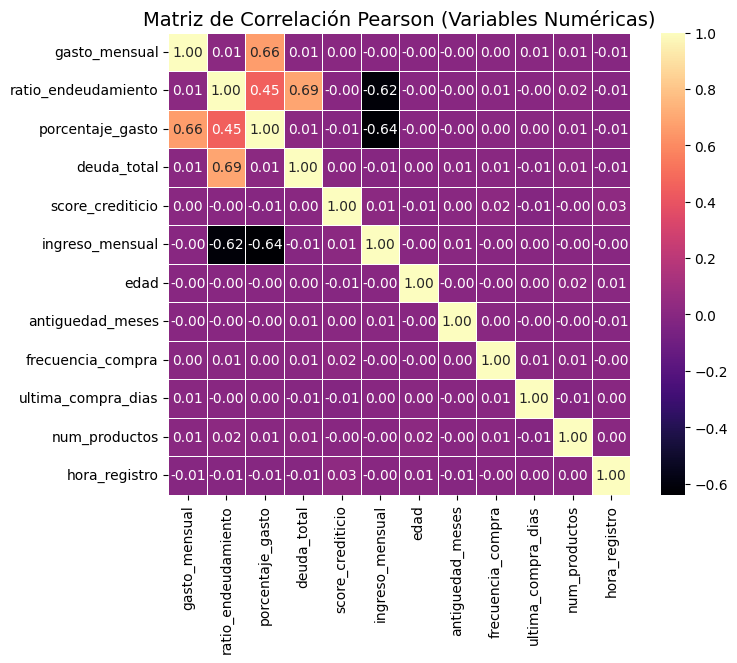

In [104]:
# Graficar heatmap de matriz de correlación
plt.figure(figsize=(8, 6))  # tamaño de la figura
sns.heatmap(
    correlaciones,
    annot=True,       # mostrar los valores
    cmap="magma",     # paleta de colores
    fmt=".2f",        # formato decimal
    square=True,      # cuadrados uniformes
    linewidths=0.5    # líneas entre celdas
)
plt.title("Matriz de Correlación Pearson (Variables Numéricas)", fontsize=14)
plt.show()

In [105]:
# Calcular la matriz de correlaciones Spearman (sólo valores numéricos)
correlaciones_spearman = data[numerical_features].corr(method="spearman")

# Ver correlación con la variable objetivo
correlacion_objetivo_spearman = correlaciones_spearman[target].sort_values(ascending=False)

correlacion_objetivo_spearman

gasto_mensual          1.000000
porcentaje_gasto       0.707539
ratio_endeudamiento    0.009353
num_productos          0.004546
score_crediticio       0.003920
deuda_total            0.003578
frecuencia_compra      0.003351
ultima_compra_dias     0.003147
edad                   0.001875
antiguedad_meses      -0.001972
ingreso_mensual       -0.004115
hora_registro         -0.005736
Name: gasto_mensual, dtype: float64

In [106]:
variables_discretas = [
    "gasto_mensual",
    "tiene_tarjeta_credito_0",
    "tiene_tarjeta_credito_1",
    "genero_Femenino",
    "genero_Masculino",
    "genero_Otro",
    "region_Centro",
    "region_Norte",
    "region_Sur",
    "estado_civil_Casado",
    "estado_civil_Divorciado",
    "estado_civil_Soltero",
    "canal_registro_App",
    "canal_registro_Tienda",
    "canal_registro_Web",
    "dia_semana_registro_Domingo",
    "dia_semana_registro_Jueves",
    "dia_semana_registro_Lunes",
    "dia_semana_registro_Martes",
    "dia_semana_registro_Miercoles",
    "dia_semana_registro_Sabado",
    "dia_semana_registro_Viernes",
    "tipo_plan",
    "uso_app",
    "abandono"
]

In [107]:
# Matriz de correlación de spearman sólo con variables discretas
correlaciones_spearman = data[variables_discretas].corr(method='spearman')
correlaciones_spearman[target].sort_values(ascending=False)
correlaciones_spearman


,gasto_mensual,tiene_tarjeta_credito_0,tiene_tarjeta_credito_1,genero_Femenino,genero_Masculino,genero_Otro,region_Centro,region_Norte,region_Sur,estado_civil_Casado,...,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app,abandono
gasto_mensual,1.000000,-0.003685,0.003685,0.004446,-0.005263,0.000790,-0.004230,0.011412,-0.007183,0.001438,...,-0.001578,0.009715,0.005055,0.000771,0.004933,-0.006339,-0.012740,0.016301,0.007928,-0.011172
tiene_tarjeta_credito_0,-0.003685,1.000000,-1.000000,-0.004506,0.001326,0.003157,0.005481,-0.001413,-0.004063,0.002195,...,-0.010522,0.000797,0.001225,-0.004054,0.006316,-0.000650,0.006821,0.005512,0.012871,0.000173
tiene_tarjeta_credito_1,0.003685,-1.000000,1.000000,0.004506,-0.001326,-0.003157,-0.005481,0.001413,0.004063,-0.002195,...,0.010522,-0.000797,-0.001225,0.004054,-0.006316,0.000650,-0.006821,-0.005512,-0.012871,-0.000173
genero_Femenino,0.004446,-0.004506,0.004506,1.000000,-0.489248,-0.508237,0.000344,0.000427,-0.000771,-0.014113,...,-0.004621,-0.000643,-0.004389,0.004815,-0.000090,0.010121,-0.005148,0.009017,-0.013391,-0.004535
genero_Masculino,-0.005263,0.001326,-0.001326,-0.489248,1.000000,-0.502453,0.002292,-0.006882,0.004591,0.013140,...,0.006466,0.002848,0.002129,-0.006588,0.001362,-0.009457,0.003184,-0.003475,0.009435,-0.001049
genero_Otro,0.000790,0.003157,-0.003157,-0.508237,-0.502453,1.000000,-0.002604,0.006373,-0.003770,0.001015,...,-0.001804,-0.002175,0.002249,0.001732,-0.001255,-0.000694,0.001959,-0.005507,0.003958,0.005531
region_Centro,-0.004230,0.005481,-0.005481,0.000344,0.002292,-0.002604,1.000000,-0.499419,-0.499812,0.004402,...,-0.009037,0.001906,-0.000013,0.003117,-0.000298,0.000484,0.003838,-0.011148,0.008411,0.005515
region_Norte,0.011412,-0.001413,0.001413,0.000427,-0.006882,0.006373,-0.499419,1.000000,-0.500769,-0.005643,...,0.005123,-0.003978,0.004096,-0.010031,-0.006142,0.006782,0.004321,-0.001479,0.000654,-0.016328
region_Sur,-0.007183,-0.004063,0.004063,-0.000771,0.004591,-0.003770,-0.499812,-0.500769,1.000000,0.001244,...,0.003908,0.002073,-0.004081,0.006914,0.006438,-0.007263,-0.008154,0.012617,-0.009056,0.010814
estado_civil_Casado,0.001438,0.002195,-0.002195,-0.014113,0.013140,0.001015,0.004402,-0.005643,0.001244,1.000000,...,0.006469,0.005220,-0.016957,0.004918,-0.007540,-0.003749,0.011758,-0.011293,0.015139,-0.003035


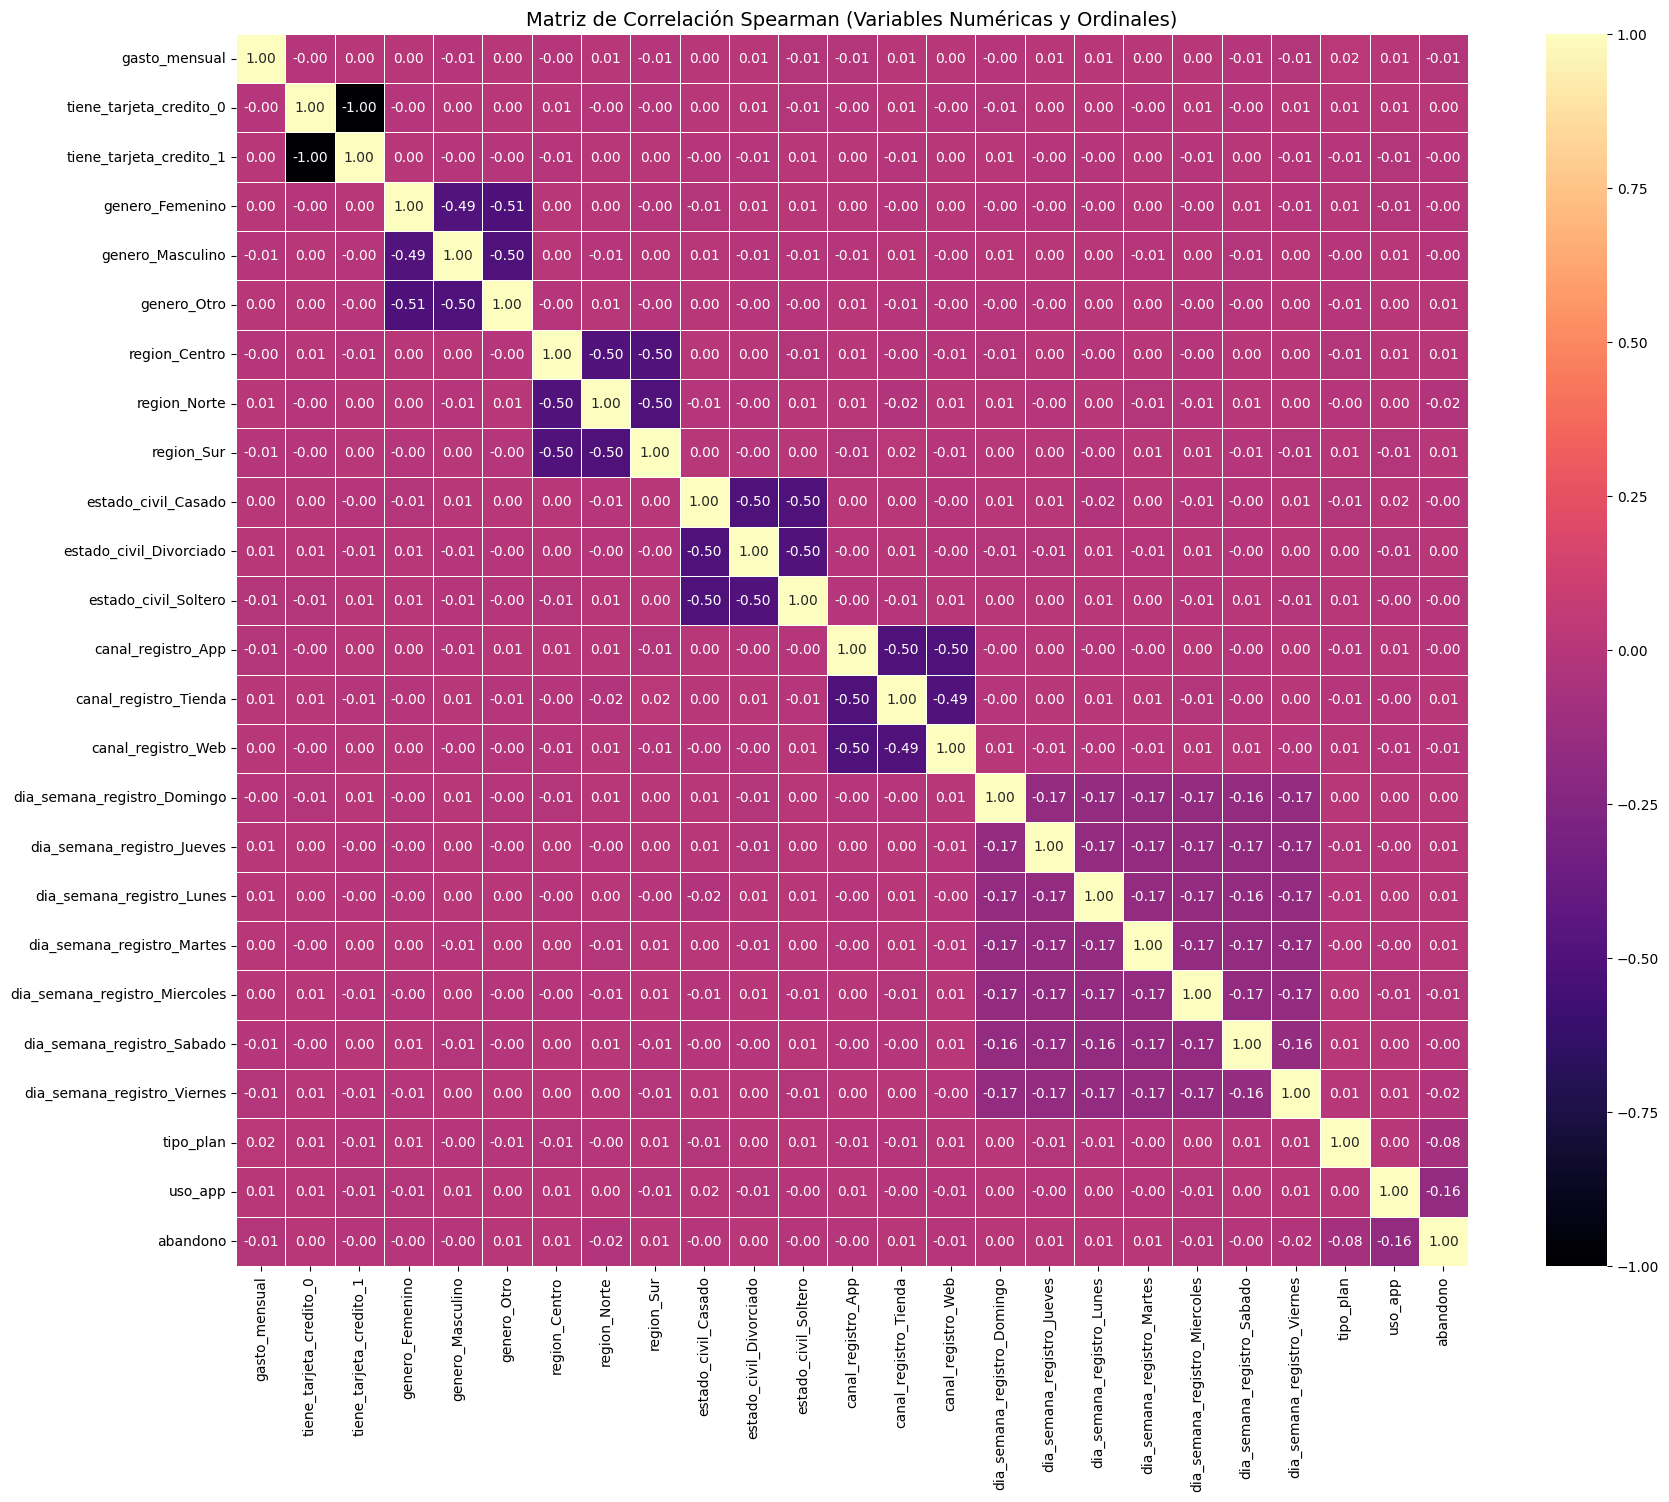

In [108]:
# Graficar heatmap
plt.figure(figsize=(20, 16))  # tamaño de la figura
sns.heatmap(
    correlaciones_spearman,
    annot=True,       # mostrar los valores
    cmap="magma",     # paleta de colores
    fmt=".2f",        # formato decimal
    square=True,      # cuadrados uniformes
    linewidths=0.5    # líneas entre celdas
)
plt.title("Matriz de Correlación Spearman (Variables Numéricas y Ordinales)", fontsize=14)
plt.show()

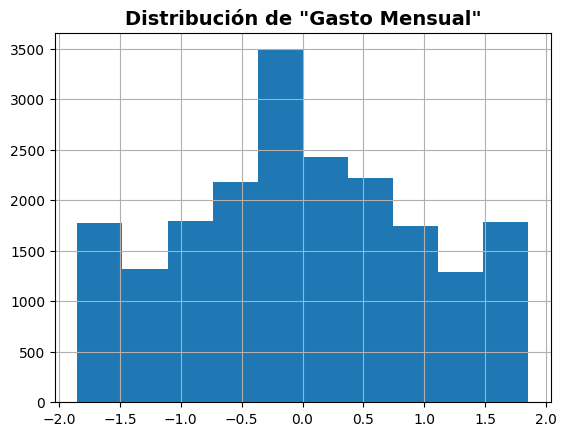

In [109]:
data["gasto_mensual"].hist()
plt.title("Distribución de \"Gasto Mensual\"", fontsize=14, fontweight="bold")
plt.show()

### Mejores variables predictoras para modelo de regresión para "gasto_mensual"

In [110]:
mejores_predictores = seleccionar_mejores_predictores(
    data,
    target,
    umbral=0.008,
)
mejores_predictores.round(4)

,variable,correlacion,correlacion_abs
ranking,,,
1,porcentaje_gasto,0.6615,0.6615
2,tipo_plan,0.0162,0.0162
3,dia_semana_registro_Viernes,-0.0134,0.0134
4,region_Norte,0.0122,0.0122
5,abandono,-0.0104,0.0104
6,canal_registro_App,-0.0099,0.0099
7,dia_semana_registro_Jueves,0.0094,0.0094
8,ratio_endeudamiento,0.0092,0.0092
9,uso_app,0.0083,0.0083


## Objetivo: "deuda_total"

In [111]:
target = "deuda_total"

In [112]:
correlacion_objetivo = calcular_correlacion_objetivo(
    data,
    target,
 )
correlacion_objetivo

deuda_total                      1.000000
ratio_endeudamiento              0.686955
abandono                         0.032325
num_productos                    0.013772
porcentaje_gasto                 0.010858
dia_semana_registro_Jueves       0.010401
dia_semana_registro_Miercoles    0.007948
canal_registro_Web               0.007834
genero_Otro                      0.007652
gasto_mensual                    0.006583
dia_semana_registro_Martes       0.005612
frecuencia_compra                0.005478
antiguedad_meses                 0.005386
estado_civil_Divorciado          0.004262
region_Norte                     0.003756
region_Sur                       0.002802
estado_civil_Soltero             0.002311
score_crediticio                 0.002102
edad                             0.001181
genero_Femenino                  0.000437
tiene_tarjeta_credito_1          0.000417
dia_semana_registro_Sabado       0.000254
tipo_plan                        0.000197
tiene_tarjeta_credito_0         -0

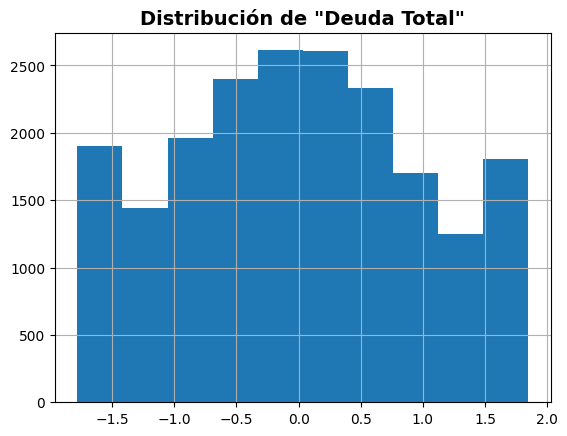

In [113]:
data[target].hist()
plt.title("Distribución de \"Deuda Total\"", fontsize=14, fontweight="bold")
plt.show()

In [114]:
mejores_predictores = seleccionar_mejores_predictores(
    data,
    target,
    umbral=0.008,
)
mejores_predictores.round(4)

,variable,correlacion,correlacion_abs
ranking,,,
1,ratio_endeudamiento,0.6870,0.6870
2,abandono,0.0323,0.0323
3,num_productos,0.0138,0.0138
4,dia_semana_registro_Lunes,-0.0121,0.0121
5,porcentaje_gasto,0.0109,0.0109
6,hora_registro,-0.0107,0.0107
7,dia_semana_registro_Jueves,0.0104,0.0104
8,dia_semana_registro_Viernes,-0.0088,0.0088
9,genero_Masculino,-0.0082,0.0082


## Objetivo: "score_crediticio"

In [115]:
target = "score_crediticio"

In [116]:
correlacion_objetivo = calcular_correlacion_objetivo(
    data,
    target,
 )
correlacion_objetivo

score_crediticio                 1.000000
hora_registro                    0.025147
frecuencia_compra                0.015746
region_Centro                    0.011306
ingreso_mensual                  0.010632
dia_semana_registro_Miercoles    0.009399
canal_registro_App               0.008960
dia_semana_registro_Lunes        0.005801
gasto_mensual                    0.004553
dia_semana_registro_Martes       0.003766
antiguedad_meses                 0.003608
dia_semana_registro_Sabado       0.003526
estado_civil_Soltero             0.003507
estado_civil_Divorciado          0.003492
genero_Otro                      0.002105
deuda_total                      0.002102
uso_app                          0.001130
genero_Femenino                  0.000420
region_Norte                     0.000117
tiene_tarjeta_credito_0          0.000106
tiene_tarjeta_credito_1         -0.000106
ratio_endeudamiento             -0.001151
num_productos                   -0.001486
canal_registro_Tienda           -0

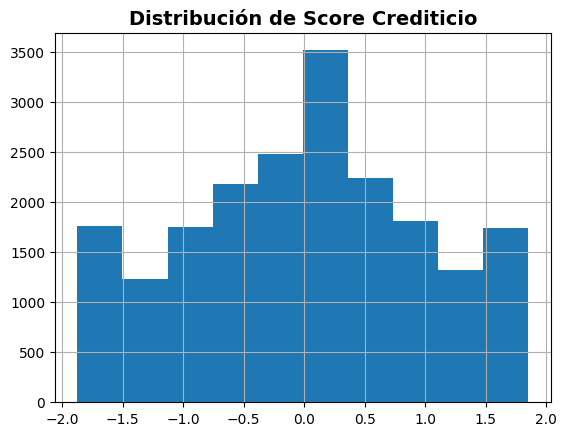

In [117]:
data[target].hist()
plt.title("Distribución de \"Score Crediticio\"", fontsize=14, fontweight="bold")
plt.show()

In [118]:
mejores_predictores = seleccionar_mejores_predictores(
    data,
    target,
    umbral=0.008,
)
mejores_predictores.round(4)

,variable,correlacion,correlacion_abs
ranking,,,
1,abandono,-0.0267,0.0267
2,hora_registro,0.0251,0.0251
3,frecuencia_compra,0.0157,0.0157
4,dia_semana_registro_Domingo,-0.0124,0.0124
5,ultima_compra_dias,-0.0115,0.0115
6,region_Sur,-0.0114,0.0114
7,region_Centro,0.0113,0.0113
8,ingreso_mensual,0.0106,0.0106
9,dia_semana_registro_Miercoles,0.0094,0.0094


## Objetivo: "ingreso_mensual"

In [119]:
target = "ingreso_mensual"

In [120]:
correlacion_objetivo = calcular_correlacion_objetivo(
    data,
    target,
 )
correlacion_objetivo

ingreso_mensual                  1.000000
tiene_tarjeta_credito_0          0.013801
estado_civil_Casado              0.011799
score_crediticio                 0.010632
region_Centro                    0.009390
dia_semana_registro_Miercoles    0.007811
tipo_plan                        0.007099
antiguedad_meses                 0.005850
genero_Otro                      0.004837
dia_semana_registro_Sabado       0.004165
abandono                         0.003754
dia_semana_registro_Lunes        0.003088
dia_semana_registro_Martes       0.002895
genero_Masculino                 0.002331
canal_registro_Tienda            0.002176
ultima_compra_dias               0.001489
dia_semana_registro_Jueves       0.001063
canal_registro_App              -0.000117
edad                            -0.000171
hora_registro                   -0.000650
num_productos                   -0.001008
uso_app                         -0.001237
region_Sur                      -0.001999
canal_registro_Web              -0

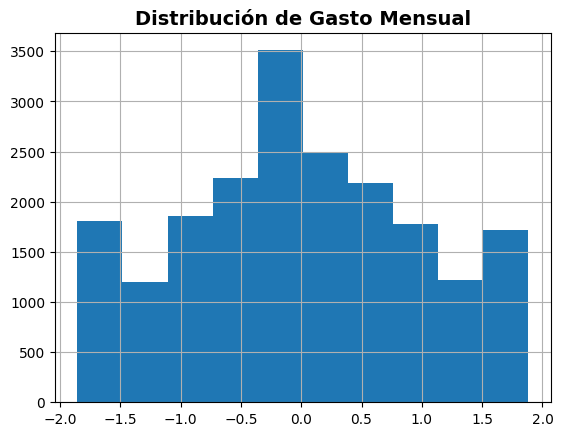

In [121]:
data[target].hist()
plt.title("Distribución de \"Ingreso Mensual\"", fontsize=14, fontweight="bold")
plt.show()

In [122]:
mejores_predictores = seleccionar_mejores_predictores(
    data,
    target,
    umbral=0.008,
)
mejores_predictores.round(4)

,variable,correlacion,correlacion_abs
ranking,,,
1,porcentaje_gasto,-0.6386,0.6386
2,ratio_endeudamiento,-0.6191,0.6191
3,tiene_tarjeta_credito_1,-0.0138,0.0138
4,tiene_tarjeta_credito_0,0.0138,0.0138
5,dia_semana_registro_Viernes,-0.0128,0.0128
6,estado_civil_Casado,0.0118,0.0118
7,score_crediticio,0.0106,0.0106
8,region_Centro,0.0094,0.0094


# Variable para modelos de clasificación

In [123]:
target = "abandono"

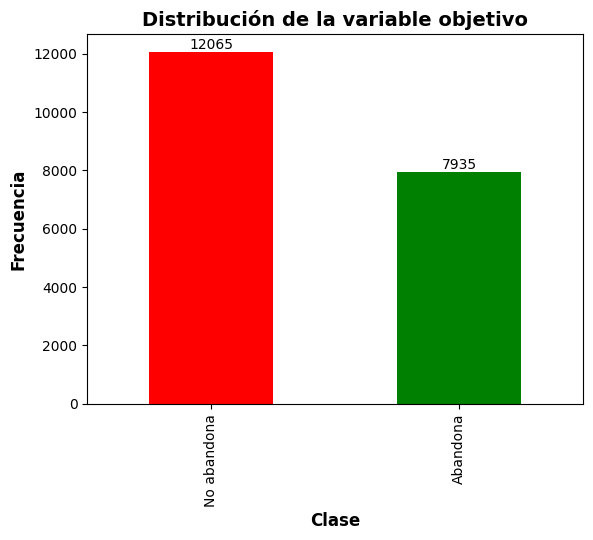

In [124]:
# Graficar la distribución de la variable objetivo
data[target].value_counts().plot(kind="bar", color=["red", "green"])
plt.title("Distribución de la variable objetivo", fontweight="bold", fontsize=14)
plt.xlabel("Clase", fontweight="bold", fontsize=12)
plt.ylabel("Frecuencia", fontweight="bold", fontsize=12)
# Agregar los nombres de las clases en el eje (0 = No, 1 = Si)
plt.xticks([0, 1], ["No abandona", "Abandona"])
# Agrega las etiquetas a cada clase
for i, count in enumerate(data[target].value_counts()):
    plt.text(i, count, str(count), ha="center", va="bottom")
plt.show()

In [125]:
correlacion_objetivo = calcular_correlacion_objetivo(
    data,
    target,
 )
correlacion_objetivo

abandono                         1.000000
ultima_compra_dias               0.212568
deuda_total                      0.032325
ratio_endeudamiento              0.019814
dia_semana_registro_Jueves       0.012692
region_Sur                       0.010814
dia_semana_registro_Lunes        0.008319
dia_semana_registro_Martes       0.007734
hora_registro                    0.007570
canal_registro_Tienda            0.007372
edad                             0.006443
genero_Otro                      0.005531
region_Centro                    0.005515
estado_civil_Divorciado          0.004422
ingreso_mensual                  0.003754
dia_semana_registro_Domingo      0.001531
tiene_tarjeta_credito_0          0.000173
tiene_tarjeta_credito_1         -0.000173
canal_registro_App              -0.000696
genero_Masculino                -0.001049
estado_civil_Soltero            -0.001378
num_productos                   -0.002758
estado_civil_Casado             -0.003035
dia_semana_registro_Sabado      -0

In [126]:
# Calcular la matriz de correlaciones (sólo valores numéricos)
numerical_features = ["abandono", "ratio_endeudamiento", "porcentaje_gasto", "gasto_mensual", "score_crediticio", "ingreso_mensual", "deuda_total", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas
correlaciones = data[numerical_features].corr(method="pearson")

# Ver correlación con la variable objetivo
correlacion_objetivo = correlaciones[target].sort_values(ascending=False)

correlacion_objetivo

abandono               1.000000
ultima_compra_dias     0.212568
deuda_total            0.032325
ratio_endeudamiento    0.019814
hora_registro          0.007570
edad                   0.006443
ingreso_mensual        0.003754
num_productos         -0.002758
antiguedad_meses      -0.006374
porcentaje_gasto      -0.007265
gasto_mensual         -0.010374
score_crediticio      -0.026656
frecuencia_compra     -0.044897
Name: abandono, dtype: float64

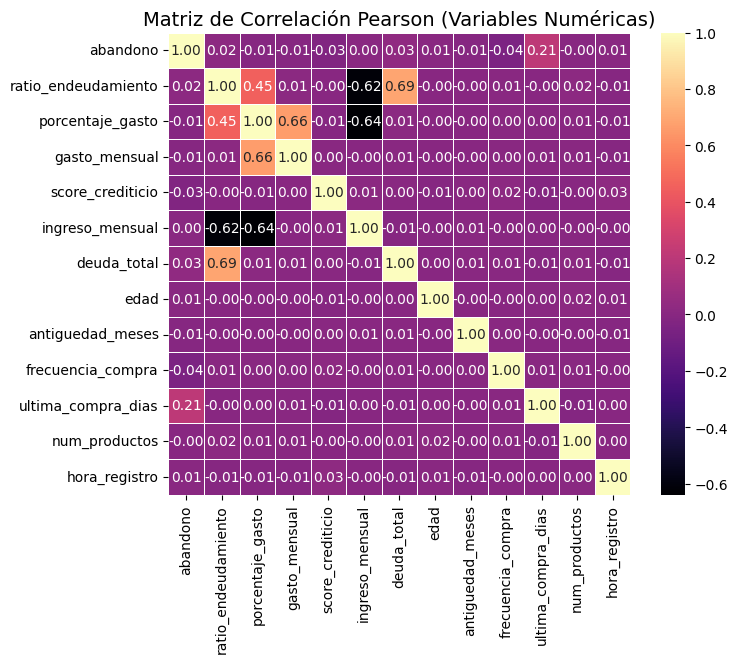

In [127]:
# Heatmap matriz de correlación
plt.figure(figsize=(8, 6))  # tamaño de la figura
sns.heatmap(
    correlaciones,
    annot=True,       # mostrar los valores
    cmap="magma",     # paleta de colores
    fmt=".2f",        # formato decimal
    square=True,      # cuadrados uniformes
    linewidths=0.5    # líneas entre celdas
)
plt.title("Matriz de Correlación Pearson (Variables Numéricas)", fontsize=14)
plt.show()

## Mejores variables predictoras para los modelos de clasificación

In [128]:
mejores_predictores_clasif = seleccionar_mejores_predictores_clasificacion(
    data,
    target,
    umbral=0.008,
)
mejores_predictores_clasif.sort_values("correlacion_abs", ascending=False).round(4)

,variable,correlacion,correlacion_abs
ranking,,,
1,ultima_compra_dias,0.2126,0.2126
2,uso_app,-0.1647,0.1647
3,tipo_plan,-0.0824,0.0824
4,frecuencia_compra,-0.0449,0.0449
5,deuda_total,0.0323,0.0323
6,score_crediticio,-0.0267,0.0267
7,ratio_endeudamiento,0.0198,0.0198
8,dia_semana_registro_Viernes,-0.0172,0.0172
9,region_Norte,-0.0163,0.0163
